# Download ordered imagery

In [18]:
import json, requests

import pandas as pd
import geopandas as gpd

from airbus_helper import *
from tqdm.notebook import tqdm

from shapely import from_geojson
from shapely.geometry import Point, Polygon, box, shape

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
ORDER_URL = "https://order.api.oneatlas.airbus.com/api/v1"
DATA_URL = "https://data.api.oneatlas.airbus.com/api/v1"
PNEO_SEARCH_URL = "https://order.api.oneatlas.airbus.com/api/v2"
WORKSPACE_SEARCH_URL = "https://search.foundation.api.oneatlas.airbus.com/api/v2/opensearch"

api_token = get_api_key("AIRBUS") #input("Enter your access token")
access_token = get_airbus_token(api_token)

headers = {
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json"
}

In [3]:
# Get all account information
ll_account_info = requests.get(f"{DATA_URL}/me", headers=headers).json()
living_library_contract_id = ll_account_info['contract']['id']
workspace_id = ll_account_info['contract']['workspaceId']

# Get PNEO account information
account_info = requests.get(f"{ORDER_URL}/contracts", headers=headers).json()
pneo_contract_id = account_info['contracts'][0]['contractId'] # 0 is PNEO, 1 is World Bank Orders (50 cm)

In [4]:
# List all orders under PNEO contract
headers = {
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json"
}

# 3. Pagination goes in the query string
query_params = {
    "limit": 10,
    "offset": 0
}

# 4. Filters go in the JSON body
json_body = {
    "contractId": pneo_contract_id,
    "paging": {
        "itemsPerPage": 100,
        "startIndex": 0,
        "pagingMode": "item"
    },
    "criteria": {
        "q": f"contractId:{pneo_contract_id}"
    }
}
     
orders_response = requests.post(f"{PNEO_SEARCH_URL}/orders/search", headers=headers, params=query_params, json=json_body)
pneo_orders = orders_response.json()

In [8]:
for item in pneo_orders['features']:
    print(f"{item['customerReference']} - {item['orderItemId']}")
    if item['orderItemId'] == "WOI_000576115_11":
        break

pneo_item = item

JOBURG HD15 sample NO COST - WOI_000594281_2
JOBURG HD15 sample NO COST - WOI_000594281_1
Atishay - Gaza - WOI_000585095_4
Atishay - Gaza - WOI_000585095_3
Atishay - Gaza - WOI_000585095_2
Atishay - Gaza - WOI_000585095_1
SPARC-Joburg - WOI_000576115_9
SPARC-Joburg - WOI_000576115_8
SPARC-Joburg - WOI_000576115_7
SPARC-Joburg - WOI_000576115_6
SPARC-Joburg - WOI_000576115_5
SPARC-Joburg - WOI_000576115_4
SPARC-Joburg - WOI_000576115_3
SPARC-Joburg - WOI_000576115_2
SPARC-Joburg - WOI_000576115_13
SPARC-Joburg - WOI_000576115_12
SPARC-Joburg - WOI_000576115_11


In [9]:
# List all orders in current workspace
headers = {
    "Authorization": f"Bearer {access_token}",
    "Content-Type": "application/json"
}

# 3. Pagination goes in the query string
query_params = {
    "limit": 50,
    "offset": 0
}

# 4. Filters go in the JSON body
json_body = {
    "contractId": pneo_contract_id,
    "workspace": workspace_id
}

workspace_res = requests.post(f"{WORKSPACE_SEARCH_URL}", headers=headers, params=query_params, json=json_body)
workspace_res.json()

{'error': False,
 'itemsPerPage': 50,
 'startIndex': 0,
 'totalResults': 6,
 'type': 'FeatureCollection',
 'features': [{'_links': {'delete': {'href': 'https://search.foundation.api.oneatlas.airbus.com/api/v1/items/ace455b2-f442-408a-b502-9fc287ec54f3',
     'name': 'Delete',
     'type': 'HTTP'},
    'download': [{'href': 'https://access.foundation.api.oneatlas.airbus.com/api/v1/items/ace455b2-f442-408a-b502-9fc287ec54f3/download',
      'name': 'Download',
      'resourceId': 'WO_000594281_2_1_SAL26565327-1_ACQ_PNEO4_07028105378004.zip',
      'type': 'HTTP'},
     {'href': 'ftpes://deliver-ftp.foundation.api.oneatlas.airbus.com/airbus-format-elklapis/WO_000594281_2_1_SAL26565327-1_ACQ_PNEO4_07028105378004.zip',
      'name': 'Download',
      'resourceId': 'WO_000594281_2_1_SAL26565327-1_ACQ_PNEO4_07028105378004.zip',
      'type': 'FTP'},
     {'href': 'https://access.foundation.api.oneatlas.airbus.com/api/v1/items/ace455b2-f442-408a-b502-9fc287ec54f3/download/dimapV2-pleiadesNeo/W

In [10]:
for item in workspace_res.json()['features']:
    print(f"{item['properties']['customerReference']} - {item['properties']['correlationId']}")
    if item['properties']['correlationId'] == "PWOI_000576115_11_1_D_1":
        cItem = item

JOBURG HD15 sample NO COST - PWOI_000594281_2_1_D_1
JOBURG HD15 sample NO COST - PWOI_000594281_1_1_D_1
Atishay - Gaza - PWOI_000585095_1_1_D_1
Atishay - Gaza - PWOI_000585095_3_1_D_1
Atishay - Gaza - PWOI_000585095_2_1_D_1
Atishay - Gaza - PWOI_000585095_4_1_D_1


In [22]:
pneo_item

{'aoi': {'name': 'Polygon 1',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[27.984494094966575, -25.901484579208883],
     [27.93668677809695, -25.905403211739184],
     [27.903770264842446, -25.92578010089673],
     [27.893581820263666, -25.95399425511488],
     [27.904553991348507, -25.970452511742124],
     [27.920228521469696, -25.972803691260296],
     [27.914742435927273, -26.01434119608146],
     [27.876339837130367, -26.062148512951083],
     [27.844990776887986, -26.054311247890503],
     [27.835586058815267, -26.077039316566214],
     [27.782292656403218, -26.182058668378176],
     [27.76740185278809, -26.211056549102395],
     [27.718027082906342, -26.1914633864509],
     [27.711757270857863, -26.21811008765693],
     [27.74467378411236, -26.28786174669623],
     [27.787778741945637, -26.308630499106812],
     [27.82539761423649, -26.31803521717952],
     [27.806588178091065, -26.365842534049143],
     [27.748592416642655, -26.360356448506742],
     [27.757997134715

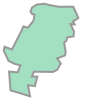

In [26]:
order_shape = Polygon(pneo_item['aoi']['geometry']['coordinates'][0])
order_dataframe = gpd.GeoDataFrame(geometry=[order_shape], crs=4326)
order_dataframe['ID'] = 1
order_dataframe.union_all()

In [11]:
with requests.get(cItem['_links']['download'][1]['href'], headers=headers, stream=True) as r:
        r.raise_for_status()
        with open("C:/Temp/IMG.zip", 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192): 
                f.write(chunk)


InvalidSchema: No connection adapters were found for 'ftpes://deliver-ftp.foundation.api.oneatlas.airbus.com/airbus-format-elklapis/WO_000576115_11_1_SAL26547352-1_ACQ_PNEO3_06911804606050.zip'